# 01 — Formulación del MDP: Persecución e Intercepción de Balón

Formulación de la tupla $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}, R, \gamma \rangle$ para la tarea acotada,
con la justificación analítica de la discretización y el dimensionamiento de la tabla $Q(s,a)$.

La especificación ejecutable es `src/SPEC.md`: frames, temporización, captura, truncamiento y registro de
evidencia. Aquí se usan directamente los módulos de `src/` (`discretizer`, `sim_env`, `params`), así que lo que
se describe es exactamente lo que se entrena. Los parámetros físicos son los que reporta el servidor real en el
handshake (`notebooks/artifacts/server_params.json`).

In [1]:
import os, math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

os.chdir("/workspace") if os.path.isdir("/workspace/src") else None
from src import plots
from src.params import load_params
from src.discretizer import Discretizer, DiscretizerConfig
from src.env_base import ACTION_NAMES, CAPTURE_RADIUS, STEP_PENALTY, CAPTURE_BONUS, T_MAX
from src.sim_env import SimBallPursuitEnv
from src.feasibility import dash_cycles
from src.sampler import sample_start

P = load_params("notebooks/artifacts/server_params.json")
disc = Discretizer()          # representación elegida (C)
keys = ["dash_power_rate", "player_decay", "player_speed_max", "inertia_moment", "player_rand",
        "visible_angle", "visible_distance", "send_step", "simulator_step", "stamina_max", "stamina_inc_max"]
display(Markdown("| parámetro del servidor | valor |\n|---|---|\n" + "\n".join(f"| `{k}` | {P[k]} |" for k in keys)))

| parámetro del servidor | valor |
|---|---|
| `dash_power_rate` | 0.006 |
| `player_decay` | 0.4 |
| `player_speed_max` | 1.05 |
| `inertia_moment` | 5.0 |
| `player_rand` | 0.1 |
| `visible_angle` | 90.0 |
| `visible_distance` | 3.0 |
| `send_step` | 150.0 |
| `simulator_step` | 100.0 |
| `stamina_max` | 8000.0 |
| `stamina_inc_max` | 45.0 |

## 1. Dinámica subyacente (de dónde sale $\mathcal{P}$)

Un paso de decisión es **un ciclo del servidor** (100 ms), con un comando de cuerpo por ciclo. Por ciclo, con
velocidad $\mathbf{v}$, rumbo del cuerpo $\phi$ y ruido $\epsilon \sim U[-r, r]$, $r = $ `player_rand` $= 0.1$:

$$\texttt{DASH } p:\quad \mathbf{v} \leftarrow \mathbf{v} + p \cdot 0.006 \cdot (\cos\phi, \sin\phi), \qquad
\texttt{TURN } m:\quad \phi \leftarrow \phi + \frac{m\,(1+\epsilon)}{1 + 5\,\lVert\mathbf{v}\rVert}$$

$$\lVert\mathbf{v}\rVert \le 1.05,\quad \mathbf{v} \leftarrow \mathbf{v} + \boldsymbol{\eta},\ \eta_i \sim U[-r\lVert\mathbf{v}\rVert,\, r\lVert\mathbf{v}\rVert],\quad
\mathbf{x} \leftarrow \mathbf{x} + \mathbf{v},\quad \mathbf{v} \leftarrow 0.4\,\mathbf{v}$$

Dos consecuencias gobiernan el diseño:
- **Velocidad de crucero ≈ 1 m/ciclo** sin ruido (desde el reposo se recorren 0.6, 0.84, 0.94, … m). En el
  modelo sin ruido, la distancia inicial fija una cota inferior en ciclos. El ruido se suma después del tope de
  velocidad, así que un ciclo puede recorrer hasta ≈ 1.155 m y esa cota no es estricta con ruido.
- **El giro efectivo depende de la velocidad:** 35° en reposo, pero solo ≈ 12° tras un dash (velocidad residual
  0.4 m/ciclo). Además, en reposo los rumbos alcanzables están **cuantizados en pasos de 35°**.

Ambas se verificaron contra el servidor (`03_live_validation.ipynb` §3): sesgo de posición ≤ 0.16 m,
giro en reposo 35.03° ± 0.16 (n = 180), giro en movimiento dentro de 0.6° de la fórmula.

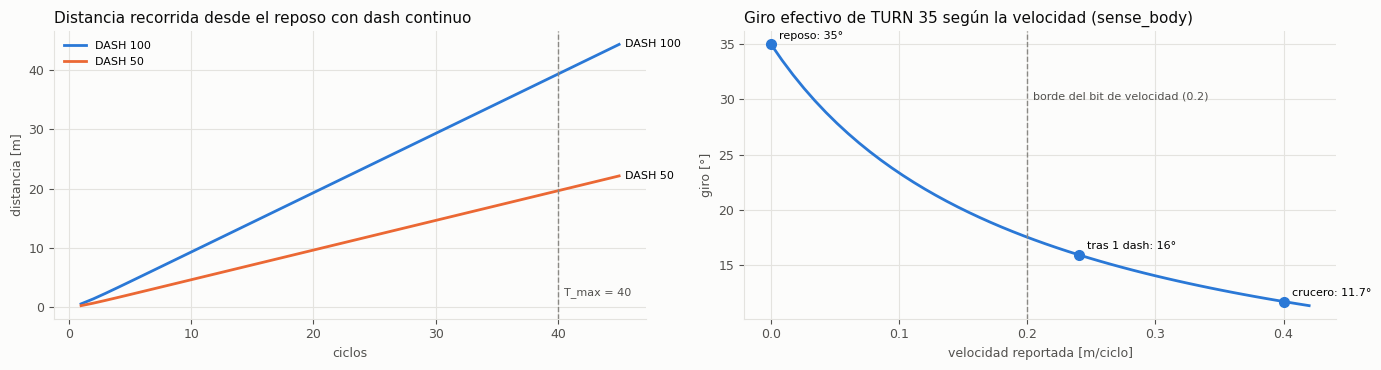

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
cyc = np.arange(1, 46)
d100, d50 = [], []
for power, out in ((100, d100), (50, d50)):
    x = v = 0.0
    for _ in cyc:
        u = min(v + power * P["dash_power_rate"], P["player_speed_max"]); x += u; v = u * P["player_decay"]; out.append(x)
for i, (y, lab) in enumerate(((d100, "DASH 100"), (d50, "DASH 50"))):
    axes[0].plot(cyc, y, color=plots.SERIES[i], linewidth=2, label=lab)
    axes[0].annotate(lab, (cyc[-1], y[-1]), xytext=(4, 0), textcoords="offset points", fontsize=8, va="center")
axes[0].axvline(T_MAX, color=plots.REF, linestyle="--", linewidth=1)
axes[0].annotate("T_max = 40", (T_MAX, 2), xytext=(4, 0), textcoords="offset points", fontsize=8, color=plots.TEXT_2)
plots.style(axes[0], "Distancia recorrida desde el reposo con dash continuo", "ciclos", "distancia [m]")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")

speed = np.linspace(0, 0.42, 50)
axes[1].plot(speed, 35 / (1 + P["inertia_moment"] * speed), color=plots.SERIES[0], linewidth=2)
for s_, lab in ((0.0, "reposo: 35°"), (0.24, "tras 1 dash: 16°"), (0.4, "crucero: 11.7°")):
    axes[1].plot(s_, 35 / (1 + 5 * s_), "o", color=plots.SERIES[0], markersize=7)
    axes[1].annotate(lab, (s_, 35 / (1 + 5 * s_)), xytext=(6, 4), textcoords="offset points", fontsize=8)
axes[1].axvline(0.2, color=plots.REF, linestyle="--", linewidth=1)
axes[1].annotate("borde del bit de velocidad (0.2)", (0.2, 30), xytext=(4, 0), textcoords="offset points", fontsize=8, color=plots.TEXT_2)
plots.style(axes[1], "Giro efectivo de TURN 35 según la velocidad (sense_body)", "velocidad reportada [m/ciclo]", "giro [°]")
fig.tight_layout(); fig.savefig("notebooks/artifacts/fig_mdp_dynamics.png", dpi=200)

## 2. Espacio de estados $\mathcal{S}$

El estado se construye **solo con lo que percibe el jugador**: el estimador `perception.BallEstimator` combina
los `see` (cono de visión de 90°, 2 de cada 3 ciclos) con la odometría del `sense_body`. Con eso,

$$s = \big(\,b_d(\hat d),\ b_\theta(\hat\theta),\ b_v(v)\,\big) \;\cup\; \{\texttt{UNKNOWN}\} \;\cup\; \{\text{captura (terminal)}\}$$

| componente | bordes | justificación |
|---|---|---|
| distancia $b_d$ | 3, 10, 20 m (4 bins, el último abierto) | 3 m = `visible_distance`: dentro de ese radio el balón se percibe en cualquier dirección y quedan ≈ 3 ciclos para capturar. Con ≈ 1 m/ciclo, 10 y 20 m separan regímenes de tiempo restante (≈ 10, 20, > 20 ciclos) frente al presupuesto de 40. |
| ángulo $b_\theta$ | ±17.5°, ±90° (5 bins) | ±17.5° = **mitad del cuanto de giro** (35°): cualquier rumbo puede llevarse al bin frontal girando en reposo, lo que no ocurre con un frente más estrecho. ±90° separa balón delante / detrás: detrás, un dash aumenta la distancia. Detrás se distingue el lado para saber hacia dónde girar. |
| velocidad $b_v$ | 0.2 m/ciclo (2 bins) | El giro efectivo cae de 35° a ≈ 12° con la velocidad (§1): sin este bit, el mismo bin exige acciones distintas y la política oscila. |
| `UNKNOWN` | 1 estado | Balón aún no adquirido en el episodio: la búsqueda queda dentro de la política aprendida. |
| captura | terminal | $d \le 0.8$ m. No es un bin de distancia y no tiene entradas en $Q$. |

Reglas de borde: intervalos semiabiertos $[e_i, e_{i+1})$ en distancia, y en ángulo cada borde pertenece al bin
más cercano al frente, tras envolver $\theta$ a $(-180°, 180°]$.

**Dimensionamiento:** $|\mathcal{S}| = 4 \times 5 \times 2 + 1 = 41$ estados no terminales,
$|\mathcal{A}| = 4$, tabla $Q$ de $41 \times 4 = 164$ valores. El boceto del enunciado ($|S| \approx 20$) se
amplía con el bit de velocidad y el lado posterior, justificados arriba. Con 20 000 episodios de ≈ 30 pasos
(≈ 600 000 transiciones) cada par $(s,a)$ recibe en promedio ≈ 3658 actualizaciones.

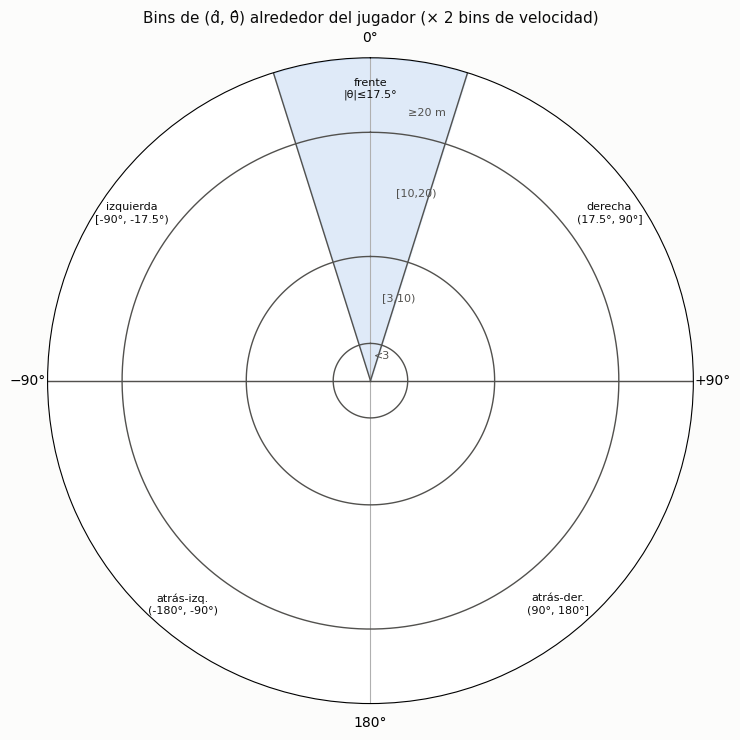

In [3]:
n = disc.n_states
display(Markdown(f"""**Dimensionamiento:** $|\\mathcal{{S}}| = {disc.n_dist} \\times {disc.n_angle} \\times {disc.n_speed} + 1 = {n}$ estados no terminales,
$|\\mathcal{{A}}| = 4$, tabla $Q$ de ${n} \\times 4 = {n * 4}$ valores. El boceto del enunciado ($|S| \\approx 20$) se
amplía con el bit de velocidad y el lado posterior, justificados arriba. Con 20 000 episodios de ≈ 30 pasos
(≈ 600 000 transiciones) cada par $(s,a)$ recibe en promedio ≈ {600000 // (n * 4)} actualizaciones."""))

fig, ax = plt.subplots(figsize=(7.5, 7.5), subplot_kw={"projection": "polar"})
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)   # 0° = frente, positivo = derecha (horario)
rmax = 26
for r_ in disc.config.distance_edges:
    ax.plot(np.linspace(0, 2 * np.pi, 200), [r_] * 200, color=plots.TEXT_2, linewidth=1)
for a_ in (17.5, -17.5, 90, -90):
    ax.plot([np.radians(a_)] * 2, [0, rmax], color=plots.TEXT_2, linewidth=1)
ax.fill_between(np.radians(np.linspace(-17.5, 17.5, 50)), 0, rmax, color=plots.SERIES[0], alpha=0.15)
for ang, lab in ((0, "frente\n|θ|≤17.5°"), (55, "derecha\n(17.5°, 90°]"), (-55, "izquierda\n[-90°, -17.5°)"),
                 (140, "atrás-der.\n(90°, 180°]"), (-140, "atrás-izq.\n(-180°, -90°)")):
    ax.text(np.radians(ang), 23.5, lab, ha="center", va="center", fontsize=8, color=plots.TEXT)
for r_, lab in ((1.8, "<3"), (6.5, "[3,10)"), (15, "[10,20)"), (21.5, "≥20 m")):
    ax.text(np.radians(8), r_, lab, fontsize=8, color=plots.TEXT_2)
ax.set_rmax(rmax); ax.set_yticks([]); ax.set_xticks(np.radians([0, 90, 180, 270]), ["0°", "+90°", "180°", "−90°"])
ax.set_title("Bins de (d̂, θ̂) alrededor del jugador (× 2 bins de velocidad)", fontsize=11, color=plots.TEXT)
fig.set_facecolor(plots.SURFACE); fig.tight_layout(); fig.savefig("notebooks/artifacts/fig_mdp_state_bins.png", dpi=200)

## 3. Espacio de acciones $\mathcal{A}$

$\mathcal{A} = \{\texttt{DASH 100},\ \texttt{DASH 50},\ \texttt{TURN +35},\ \texttt{TURN −35}\}$, una por ciclo.
`TURN +35` aumenta el rumbo del cuerpo, que es el sentido horario en el monitor, así que reduce un rumbo relativo
positivo (balón a la derecha). Se verificó en ambos entornos: un balón a +20° pasa a ≈ −15° tras `TURN +35`.

## 4. Transiciones $\mathcal{P}(s' \mid s, a)$

$\mathcal{P}$ no tiene forma cerrada sobre los bins: resulta de componer la dinámica continua (§1), el ruido de
movimiento, la cuantización de la visión y el estimador. Se caracteriza de dos formas:

1. **Cualitativamente.** Con el balón inmóvil, $\mathcal{P}$ es casi determinista dentro de cada bin. La
   estocasticidad proviene de: (i) el ruido de giro (±10 %) y de velocidad; (ii) la **posición exacta dentro del
   bin**, que el estado no contiene (p. ej. un `TURN` desde $\theta = 20°$ lleva al frente, desde $\theta = 80°$ no);
   (iii) la visión parcial: sin avistamiento, $(\hat d, \hat\theta)$ se propaga por odometría y acumula error.
2. **Empíricamente.** Se estima $\hat{\mathcal{P}}$ contando transiciones en el simulador con una política
   uniforme sobre inicios de la distribución de la tarea.

**Aproximación de Markov.** Por (ii) y (iii), $s$ no es un estado de Markov exacto: dos situaciones con el mismo
$s$ pueden tener distribuciones de $s'$ distintas. Esto es aliasing de estados, propio de una representación
tabular de un POMDP continuo. Consecuencias observadas: con $\alpha = 0.1$ la política greedy colapsaba
periódicamente, y el bit de velocidad y $\alpha = 0.03$ lo estabilizaron (`02_train_baseline.ipynb` §2).

In [4]:
rng = np.random.default_rng(0)
env = SimBallPursuitEnv(P, seed=0)
counts = np.zeros((disc.n_states, 4, disc.n_states + 1))    # última columna = terminal (captura)
for ep in range(4000):
    obs, _ = env.reset(sample_start(rng)); s = disc(obs); done = False
    while not done:
        a = int(rng.integers(4))
        obs, r, term, trunc, _ = env.step(a)
        s2 = disc.n_states if term else disc(obs)
        counts[s, a, s2] += 1; s = s2 if not term else s; done = term or trunc

ANG = ["frente", "der.", "izq.", "atrás-der.", "atrás-izq."]
def short(j):
    if j == disc.unknown_state: return "UNKNOWN"
    d, a, v = disc.decompose(j)
    return f"{disc.distance_labels()[d]} · {ANG[a]} · {'lento' if v == 0 else 'rápido'}"

def top(s, a, k=3):
    row = counts[s, a]; tot = row.sum()
    if tot == 0: return "sin datos", 0
    idx = np.argsort(row)[::-1][:k]
    lab = lambda j: "captura" if j == disc.n_states else short(j)
    return "; ".join(f"{lab(j)}: {row[j] / tot:.2f}" for j in idx if row[j] > 0), int(tot)

examples = [((1, 0, 0), "a 3-10 m, de frente, lento"), ((2, 1, 0), "a 10-20 m, a la derecha, lento"),
            ((2, 1, 1), "a 10-20 m, a la derecha, rápido"), ((0, 0, 1), "a < 3 m, de frente, rápido")]
lines = ["| estado $s$ | acción | $n$ | $\\hat{\\mathcal{P}}(s' \\mid s,a)$ (3 más probables) |", "|---|---|---|---|"]
for (db, ab, sb), desc in examples:
    s = (db * disc.n_angle + ab) * disc.n_speed + sb
    for a in range(4):
        txt, n_ = top(s, a)
        lines.append(f"| {desc} | {ACTION_NAMES[a]} | {n_} | {txt} |")
display(Markdown("\n".join(lines)))
self_loop = np.array([[counts[s, a, s] / max(counts[s, a].sum(), 1) for a in range(4)] for s in range(disc.n_states)])
print("probabilidad media de permanecer en el mismo estado por acción:",
      dict(zip(ACTION_NAMES, np.round(self_loop[counts.sum(axis=2).min(axis=1) > 0].mean(axis=0), 2))))

| estado $s$ | acción | $n$ | $\hat{\mathcal{P}}(s' \mid s,a)$ (3 más probables) |
|---|---|---|---|
| a 3-10 m, de frente, lento | DASH 100 | 305 | [3,10) · frente · rápido: 0.85; d<3 · frente · rápido: 0.07; [3,10) · der. · rápido: 0.03 |
| a 3-10 m, de frente, lento | DASH 50 | 295 | [3,10) · frente · lento: 0.85; [3,10) · der. · lento: 0.05; [3,10) · frente · rápido: 0.05 |
| a 3-10 m, de frente, lento | TURN +35 | 281 | [3,10) · izq. · lento: 0.69; [3,10) · frente · lento: 0.25; [10,20) · izq. · lento: 0.03 |
| a 3-10 m, de frente, lento | TURN -35 | 276 | [3,10) · der. · lento: 0.67; [3,10) · frente · lento: 0.28; [10,20) · der. · lento: 0.03 |
| a 10-20 m, a la derecha, lento | DASH 100 | 952 | [10,20) · der. · rápido: 0.93; [3,10) · der. · rápido: 0.03; [10,20) · atrás-der. · rápido: 0.02 |
| a 10-20 m, a la derecha, lento | DASH 50 | 899 | [10,20) · der. · lento: 0.92; [10,20) · der. · rápido: 0.03; [3,10) · der. · lento: 0.02 |
| a 10-20 m, a la derecha, lento | TURN +35 | 950 | [10,20) · der. · lento: 0.57; [10,20) · frente · lento: 0.38; d≥20 · frente · lento: 0.03 |
| a 10-20 m, a la derecha, lento | TURN -35 | 895 | [10,20) · der. · lento: 0.70; [10,20) · atrás-der. · lento: 0.27; [3,10) · der. · lento: 0.02 |
| a 10-20 m, a la derecha, rápido | DASH 100 | 446 | [10,20) · der. · rápido: 0.89; [3,10) · der. · rápido: 0.06; [10,20) · atrás-der. · rápido: 0.04 |
| a 10-20 m, a la derecha, rápido | DASH 50 | 464 | [10,20) · der. · rápido: 0.89; [10,20) · der. · lento: 0.04; [10,20) · atrás-der. · rápido: 0.03 |
| a 10-20 m, a la derecha, rápido | TURN +35 | 478 | [10,20) · der. · lento: 0.74; [10,20) · frente · lento: 0.23; d≥20 · der. · lento: 0.01 |
| a 10-20 m, a la derecha, rápido | TURN -35 | 453 | [10,20) · der. · lento: 0.82; [10,20) · atrás-der. · lento: 0.15; [3,10) · der. · lento: 0.03 |
| a < 3 m, de frente, rápido | DASH 100 | 16 | d<3 · frente · rápido: 0.50; captura: 0.38; d<3 · der. · rápido: 0.12 |
| a < 3 m, de frente, rápido | DASH 50 | 25 | d<3 · frente · rápido: 0.56; d<3 · izq. · rápido: 0.16; captura: 0.12 |
| a < 3 m, de frente, rápido | TURN +35 | 20 | d<3 · frente · lento: 0.65; d<3 · izq. · lento: 0.25; captura: 0.10 |
| a < 3 m, de frente, rápido | TURN -35 | 24 | d<3 · frente · lento: 0.71; d<3 · der. · lento: 0.29 |

probabilidad media de permanecer en el mismo estado por acción: {'DASH 100': np.float64(0.43), 'DASH 50': np.float64(0.87), 'TURN +35': np.float64(0.31), 'TURN -35': np.float64(0.3)}


Lectura de la tabla:
- **La velocidad cambia el efecto de la misma acción.** Con el balón a la derecha a 10–20 m, `TURN +35` lleva el
  balón al frente con probabilidad ≈ 0.38 en reposo, pero solo ≈ 0.23 en movimiento, porque el giro efectivo cae a
  ≈ 12°. Es la dependencia de la velocidad que motiva el bit $b_v$. El resto permanece en «derecha», porque ese
  bin abarca de 17.5° a 90° y un giro de 35° desde más allá de 52.5° no alcanza el frente. Es la posición
  dentro del bin, que el estado no contiene.
- **Permanecer en el mismo estado es frecuente,** sobre todo con `DASH 50`: los bins son amplios y un ciclo
  mueve poco.
- **Nota de diseño:** la velocidad de crucero de `DASH 50` tras el decaimiento es exactamente 0.2 m/ciclo, el borde
  del bit de velocidad, así que con `DASH 50` sostenido el estado alterna entre ambos bins. La política aprendida
  casi no usa `DASH 50`, pero un borde en 0.15 o 0.25 evitaría esa ambigüedad.

## 5. Recompensa $R$

Prescrita por el enunciado y calculada con la distancia verdadera (el simulador o la verdad de terreno del
entrenador), idéntica en ambos entornos:

$$r_t = (d_t - d_{t+1}) - 0.2 + 100\cdot\mathbb{1}\{d_{t+1} \le 0.8\}$$

**Qué optimiza.** Con $\gamma = 1$ el término de aproximación es telescópico. Para un episodio de $T$ pasos:

$$G_0 = \sum_{t=0}^{T-1} r_t = (d_0 - d_T) - 0.2\,T + 100\cdot\mathbb{1}\{\text{captura}\}$$

Si hay captura, $d_T \in (0.8 - 1.05,\ 0.8]$ es prácticamente constante, así que maximizar $G_0$ equivale a
**capturar en el menor número de pasos**, que es exactamente el objetivo de la tarea. Si no hay captura,
el agente recibe crédito por la distancia recortada ($d_0 - d_T$), lo que da señal en los episodios fallidos.

**Relación con el moldeado basado en potencial.** Con $\Phi(s) = -d(s)$, el moldeado que preserva la política
óptima bajo descuento sería $\gamma\Phi(s') - \Phi(s) = d_t - \gamma\,d_{t+1}$. El término prescrito
$d_t - d_{t+1}$ coincide solo si $\gamma = 1$. Se mantiene la recompensa del enunciado y **no se afirma
invariancia de la política**; además, esa garantía (Ng et al., 1999) supone un MDP, y aquí el estado es aproximado.

## 6. Factor de descuento $\gamma$

El episodio dura como máximo $T_{max} = 40$ pasos, así que se puede usar $\gamma$ cercano a 1. El criterio es
que el bono de captura (+100), descontado hasta el paso en que ocurre, siga dominando las penalizaciones por paso
y el término de aproximación (≈ +1/paso). Si no, el agente se vuelve indiferente entre capturar tarde o no capturar.

Con **γ = 0.99** el bono vale 67.6 en el paso 39 (horizonte efectivo
1/(1−γ) = 100 > T_max), así que sigue dominando. Con γ = 0.9 vale 1.6, ya del orden de una sola
recompensa de aproximación, y las capturas tardías, que son justamente las difíciles, casi no se distinguen de
fallar. Se usa **γ = 0.99** en todas las corridas.

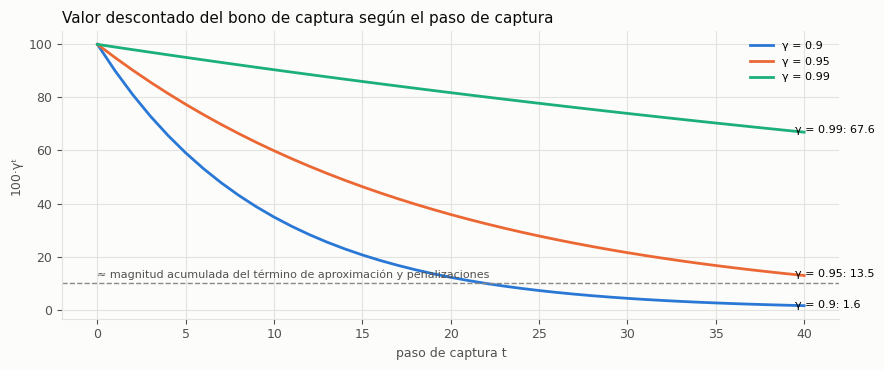

In [5]:
t = np.arange(0, 41)
fig, ax = plt.subplots(figsize=(9, 3.8))
for i, g in enumerate((0.9, 0.95, 0.99)):
    ax.plot(t, CAPTURE_BONUS * g ** t, color=plots.SERIES[i], linewidth=2, label=f"γ = {g}")
    ax.annotate(f"γ = {g}: {CAPTURE_BONUS * g ** 39:.1f}", (39, CAPTURE_BONUS * g ** 39), xytext=(6, 0),
                textcoords="offset points", fontsize=8, va="center")
ax.axhline(10, color=plots.REF, linestyle="--", linewidth=1)
ax.annotate("≈ magnitud acumulada del término de aproximación y penalizaciones", (0, 10), xytext=(0, 4),
            textcoords="offset points", fontsize=8, color=plots.TEXT_2)
plots.style(ax, "Valor descontado del bono de captura según el paso de captura", "paso de captura t", "100·γᵗ")
ax.legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout(); fig.savefig("notebooks/artifacts/fig_mdp_gamma.png", dpi=200)
display(Markdown(f"""Con **γ = 0.99** el bono vale {100 * 0.99 ** 39:.1f} en el paso 39 (horizonte efectivo
1/(1−γ) = 100 > T_max), así que sigue dominando. Con γ = 0.9 vale {100 * 0.9 ** 39:.1f}, ya del orden de una sola
recompensa de aproximación, y las capturas tardías, que son justamente las difíciles, casi no se distinguen de
fallar. Se usa **γ = 0.99** en todas las corridas."""))

## 7. Presupuesto temporal y alcanzabilidad

Con 1 paso = 1 ciclo y **sin ruido**, ninguna política captura antes de recorrer $d_0 - 0.8$ m. Además, mientras
el balón está detrás ($|\theta| > 90°$) un dash no acerca al jugador, así que primero hay que girar (≤ 35° por
ciclo). Eso da una cota inferior de ciclos válida para cualquier política en el modelo sin ruido.

Dos supuestos condicionan todo el análisis: (i) **1 paso = 1 ciclo** y (ii) **$d_0$ uniforme en [5, 40] m**. El
enunciado fija el rango pero no la distribución; la uniforme es una decisión nuestra (`sampler.py`).

En el modelo sin ruido, un balón de frente es capturable en < 40 pasos solo si $d_0 \lesssim$ 39.0 m; si
hacen falta 3 giros, el límite baja a ≈ 36.0 m.

La **cota demostrable** (giros hasta dejar el balón delante + dash recto, sin ruido) da un techo de
**94.9%** de captura en < 40 pasos (97.6% en ≤ 40) sobre la distribución uniforme.
Está **por encima de 90 %**, así que **no demuestra que el criterio sea inalcanzable**. Con ruido, además, no
hay imposibilidad estricta. Las estimaciones idealizadas pero no demostrables (≈ 89 % con giros relajados;
≈ 70 % para un controlador realizable) y los resultados medidos sugieren que el presupuesto es **muy ajustado**
para los inicios lejanos. Detalles en `src/SPEC.md` §11 y `03_live_validation.ipynb`.

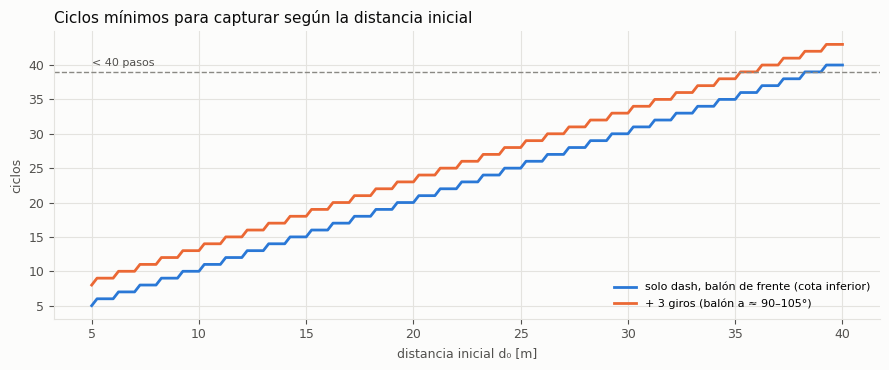

In [6]:
d0 = np.linspace(5, 40, 141)
only_dash = np.array([dash_cycles(d - CAPTURE_RADIUS, P) for d in d0])
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(d0, only_dash, color=plots.SERIES[0], linewidth=2, label="solo dash, balón de frente (cota inferior)")
ax.plot(d0, only_dash + 3, color=plots.SERIES[1], linewidth=2, label="+ 3 giros (balón a ≈ 90–105°)")
ax.axhline(39, color=plots.REF, linestyle="--", linewidth=1)
ax.annotate("< 40 pasos", (5, 39), xytext=(0, 4), textcoords="offset points", fontsize=8, color=plots.TEXT_2)
plots.style(ax, "Ciclos mínimos para capturar según la distancia inicial", "distancia inicial d₀ [m]", "ciclos")
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig("notebooks/artifacts/fig_mdp_budget.png", dpi=200)
lim0 = d0[only_dash <= 39].max(); lim3 = d0[only_dash + 3 <= 39].max()
from src.feasibility import provable_ceiling
ceil = provable_ceiling(200_000, 0, P)["ceiling"]
display(Markdown(f"""En el modelo sin ruido, un balón de frente es capturable en < 40 pasos solo si $d_0 \\lesssim$ {lim0:.1f} m; si
hacen falta 3 giros, el límite baja a ≈ {lim3:.1f} m.

La **cota demostrable** (giros hasta dejar el balón delante + dash recto, sin ruido) da un techo de
**{ceil['<40']:.1%}** de captura en < 40 pasos ({ceil['<=40']:.1%} en ≤ 40) sobre la distribución uniforme.
Está **por encima de 90 %**, así que **no demuestra que el criterio sea inalcanzable**. Con ruido, además, no
hay imposibilidad estricta. Las estimaciones idealizadas pero no demostrables (≈ 89 % con giros relajados;
≈ 70 % para un controlador realizable) y los resultados medidos sugieren que el presupuesto es **muy ajustado**
para los inicios lejanos. Detalles en `src/SPEC.md` §11 y `03_live_validation.ipynb`."""))

## 8. Resumen de la tupla

| elemento | definición |
|---|---|
| $\mathcal{S}$ | 41 estados no terminales: 4 (distancia) × 5 (ángulo) × 2 (velocidad) + `UNKNOWN`; más el terminal de captura. Representación aproximada (no Markov exacta) de un POMDP continuo. |
| $\mathcal{A}$ | {DASH 100, DASH 50, TURN +35, TURN −35}, una acción por ciclo de 100 ms |
| $\mathcal{P}$ | Inducida por la física de `rcssserver` (§1), el ruido de movimiento (±10 %), la visión parcial y el estimador. Casi determinista dentro de cada bin; estimada empíricamente en §4. |
| $R$ | $(d_t - d_{t+1}) - 0.2 + 100\cdot\mathbb{1}\{d_{t+1}\le 0.8\}$, con la distancia verdadera |
| $\gamma$ | 0.99 |
| episodio | termina con captura (terminal, sin bootstrap) o se trunca en $T_{max} = 40$ (bootstrap desde $s'$) |
| inicio | $d_0 \sim U[5,40]$ m, rumbo relativo y orientación uniformes, posición uniforme en la región factible de la cancha (`sampler.py`) |